<a href="https://colab.research.google.com/github/der41/XAI_Duke/blob/main/Notebooks/Mechanistic_Interpretability_XOR_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Mechanistic Interpretability on a Tiny Model: XOR / Parity Classifier

Analysis done by Diego Rodriguez, modifying the Mechanistic Interpretability Notebook from Dr Brinnae Brent dedicated to Counting 1s in binary strings. This notebook does not use LLMs.

**Goal:** Train a tiny MLP on a 3‑bit parity (XOR) task and then open the box to explain what one hidden neuron is doing.  

**Why parity/XOR?** It’s the smallest non‑linear task that linear models fail at. A 2‑layer MLP solves it, and its hidden neurons often become interpretable “feature detectors” for subpatterns (e.g., “first two bits equal”).  



## Part 1 — Setup

Fixed library version:



In [ ]:
from typing_extensions import dataclass_transform
import os

# Remove Colab default sample_data
!rm -r ./sample_data ./XAI_Duke

# Clone GitHub files to colab workspace
repo_name = "XAI_Duke"
git_path = 'https://github.com/der41/XAI_Duke.git'
!git clone "{git_path}"

# Install dependencies from requirements.txt file
!pip install -r "{os.path.join(repo_name,'requirements.txt')}"

rm: cannot remove './sample_data': No such file or directory
Cloning into 'XAI_Duke'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 121 (delta 50), reused 36 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 10.82 MiB | 18.22 MiB/s, done.
Resolving deltas: 100% (50/50), done.


**Task:** 3-bit parity (XOR) — Output 1 if there are an odd number of 1s in the input, else 0.  
I'll train a very small MLP so internal structure stays easy to interpret.


Train acc: 1.000 | Val acc: 1.000


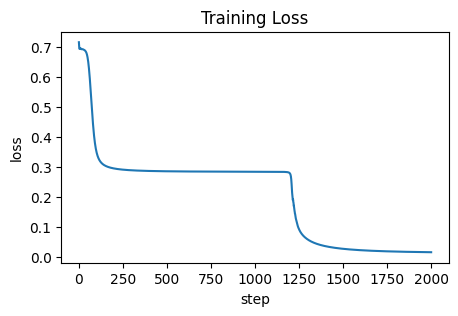

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ---- Data: all 3-bit inputs (000..111) with labels = parity ----
X_bin = np.array([[int(b) for b in f"{i:03b}"] for i in range(8)],
                 dtype=np.float32)
y = (X_bin.sum(axis=1) % 2).astype(np.float32)  # odd parity = 1

# To make it more like "training", repeat with small noise (still solvable)
def make_dataset(reps=256, noise_std=0.0):
    X = np.repeat(X_bin, reps, axis=0).astype(np.float32)
    if noise_std > 0:
        X = X + np.random.normal(0, noise_std,
                                 size=X.shape).astype(np.float32)
        X = np.clip(X, 0.0, 1.0)
    Y = np.repeat(y, reps, axis=0).astype(np.float32)
    return torch.tensor(X), torch.tensor(Y)

X_train, y_train = make_dataset(reps=256, noise_std=0.0)
X_val,   y_val   = make_dataset(reps=64,  noise_std=0.0)

# ---- Tiny model ----
class TinyMLP(nn.Module):
  '''
  Neural network with 3 dimension default
  Hidden layer with 2 neurons
  Output layer with 1 neuron
  tanh activation function
  '''
  def __init__(self, in_dim=3, hidden=2):
      super().__init__()
      self.fc1 = nn.Linear(in_dim, hidden, bias=True)
      self.act = nn.Tanh()
      self.fc2 = nn.Linear(hidden, 1, bias=True)

  def forward(self, x):
      h = self.act(self.fc1(x))
      logits = self.fc2(h)
      return logits, h

#Definin Loss and forward optimization
model = TinyMLP(in_dim=3, hidden=2)
criterion = nn.BCEWithLogitsLoss()
opt = optim.Adam(model.parameters(), lr=0.03, weight_decay=1e-4)

# ---- Train ----
def accuracy(model, X, y):
    with torch.no_grad():
        probs, _ = model(X)
        preds = (probs.view(-1) > 0.5).float()
        return (preds == y).float().mean().item()

losses = []
for epoch in range(2000):
    model.train()
    opt.zero_grad()
    logits, _ = model(X_train)
    loss = criterion(logits.view(-1), y_train)
    loss.backward()
    opt.step()
    losses.append(loss.item())

#Summary results
acc_train = accuracy(model, X_train, y_train)
acc_val   = accuracy(model, X_val, y_val)

#Plot
print(f"Train acc: {acc_train:.3f} | Val acc: {acc_val:.3f}")
plt.figure(figsize=(5,3))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()



## Part 2 — Explore and Explanation

We’ll look at:
1. **Weights** (input→hidden and hidden→output)
2. **Hidden activations** for each of the 8 canonical inputs
3. **Neuron selectivity**: how each hidden unit responds as we flip specific bits
4. **Ablation**: zero out hidden neurons to measure their functional role


W1 (hidden x input):
 [[ 4.770379    4.7744026  -4.88834   ]
 [ 0.73605704  0.73614454 -0.7389592 ]]
b1 (hidden):
 [-2.2891183  -0.36503544]
W2 (output x hidden):
 [[ 11.288364 -18.588953]]
b2 (output):
 [0.01092677]


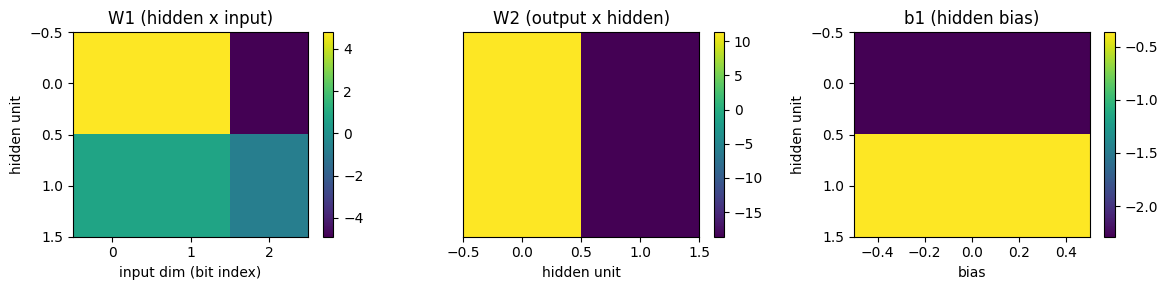

In [ ]:

# ---- Inspect Weights ----
W1 = model.fc1.weight.detach().numpy()
b1 = model.fc1.bias.detach().numpy()
W2 = model.fc2.weight.detach().numpy()
b2 = model.fc2.bias.detach().numpy()

print("W1 (hidden x input):\n", W1)
print("b1 (hidden):\n", b1)
print("W2 (output x hidden):\n", W2)
print("b2 (output):\n", b2)

# Heatmaps for readability
fig, axs = plt.subplots(1,3, figsize=(12,3))
im0 = axs[0].imshow(W1, aspect='auto')
axs[0].set_title("W1 (hidden x input)")
axs[0].set_xlabel("input dim (bit index)")
axs[0].set_ylabel("hidden unit")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(W2, aspect='auto')
axs[1].set_title("W2 (output x hidden)")
axs[1].set_xlabel("hidden unit")
axs[1].set_yticks([])
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(b1.reshape(-1,1), aspect='auto')
axs[2].set_title("b1 (hidden bias)")
axs[2].set_xlabel("bias")
axs[2].set_ylabel("hidden unit")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


The network implements parity using two complementary hidden features.
h₀ is a high-gain comparator of (x0 + x1) − x2 with a negative bias, activating strongly when the left bits dominate (especially when x2=0).it creates Z₀

h₁ is a lower-gain, thresholded comparator of the same relation that tends to activate for patterns where a single left bit is on and x2=0, and deactivate when x2=1. it creates Z₁

The output combines these in a push–pull fashion ($11.2Z₀$, $−18.5Z₁$) to produce the odd/even decision that solves the XOR problem (e.g., 001/010/100/111 high; 000/011/101/110 low).

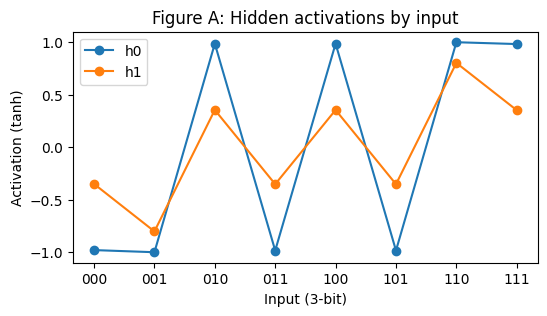

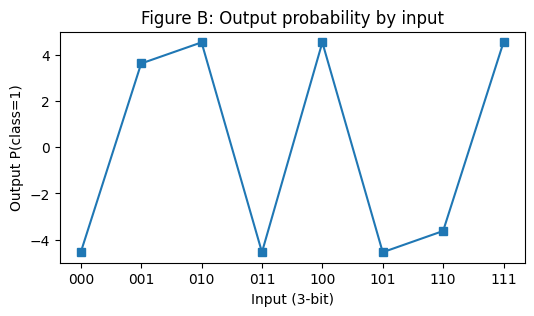

In [ ]:

# ---- Hidden activations for the 8 canonical inputs ----
with torch.no_grad():
    _, H = model(torch.tensor(X_bin))
    H = H.numpy()

fig, ax = plt.subplots(figsize=(6,3))
x_ticks = [f"{i:03b}" for i in range(8)]
for j in range(H.shape[1]):
    ax.plot(range(8), H[:, j], marker='o', label=f'h{j}')
ax.set_xticks(range(8))
ax.set_xticklabels(x_ticks, rotation=0)
ax.set_xlabel("Input (3-bit)")
ax.set_ylabel("Activation (tanh)")
ax.set_title("Figure A: Hidden activations by input")
ax.legend()
plt.show()

# Also show output probabilities for each canonical input
with torch.no_grad():
    probs, _ = model(torch.tensor(X_bin))
    probs = probs.view(-1).numpy()

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(range(8), probs, marker='s')
ax.set_xticks(range(8))
ax.set_xticklabels(x_ticks, rotation=0)
ax.set_xlabel("Input (3-bit)")
ax.set_ylabel("Output P(class=1)")
ax.set_title("Figure B: Output probability by input")
plt.show()


This shows a different format of the same information. On figure A: I observed the dynamics of h₀ and h₁, as mentioned in the weights analysis, they have similar activation direction, but on different magnitudes.

When h₀ and h₁ do have similar range values (e.g. 001 or 110) the higher activation on the second layer kicks in to provoke the XOR effect. Figure B helps to observe this assigning a high probability of odd (001) when both values are close to the lower limit of the tahn, or even (110) when they are close to the high level of the tahn.

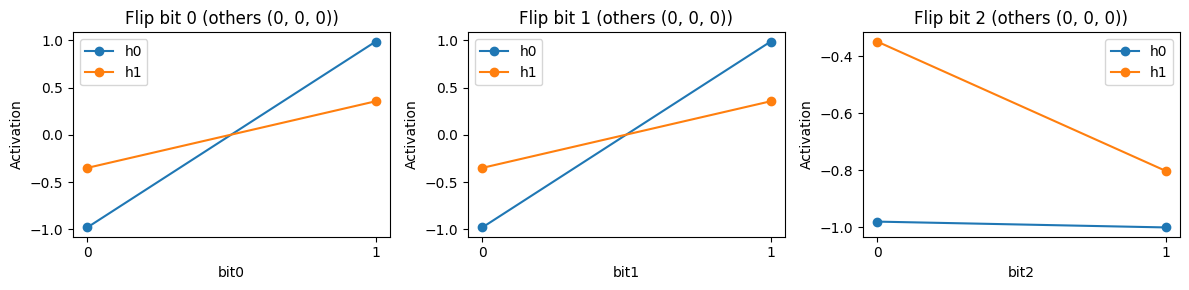

In [ ]:

# ---- Neuron selectivity curves ----
def sweep_bit(bit_index, fixed=(0,0,0)):
    # Return all 8 combos where one bit varies
    xs = []
    for v in [0,1]:
        row = list(fixed)
        row[bit_index] = v
        xs.append(row)
    return torch.tensor(xs, dtype=torch.float32)

fig, axs = plt.subplots(1,3, figsize=(12,3))
base = (0,0,0)
for bit in range(3):
    Xs = sweep_bit(bit, base)
    with torch.no_grad():
        probs, H = model(Xs)
    axs[bit].plot([0,1], H[:,0].numpy(), marker='o', label='h0')
    axs[bit].plot([0,1], H[:,1].numpy(), marker='o', label='h1')
    axs[bit].set_title(f"Flip bit {bit} (others {base})")
    axs[bit].set_xlabel(f"bit{bit}")
    axs[bit].set_ylabel("Activation")
    axs[bit].set_xticks([0,1])
    axs[bit].legend()
plt.tight_layout()
plt.show()


Each subplot shows the effect of flipping one input bit (x₀, x₁, x₂), while keeping the others at 0.
The lines show how the hidden neurons’ activations (h₀ in blue, h₁ in orange) change when that bit toggles between 0 → 1.

left bit and central bit shows a similar behavior, while the third bit will activate changes on the activation that enable XOR.

In [ ]:

# ---- Ablation ----
def predict_with_ablation(model, X, ablate_hidden=None):
    with torch.no_grad():
        h_pre = model.act(model.fc1(X))
        if ablate_hidden is not None:
            h_pre[:, ablate_hidden] = 0.0
        out = torch.sigmoid(model.fc2(h_pre))
        preds = (out.view(-1) > 0.5).float()
    return preds, out.view(-1), h_pre

def eval_ablation(ablate_hidden=None):
    preds, probs, _ = predict_with_ablation(model, X_val,
                                            ablate_hidden=ablate_hidden)
    acc = (preds == y_val).float().mean().item()
    return acc

acc_no_abl = eval_ablation(None)
acc_h0_off = eval_ablation(0)
acc_h1_off = eval_ablation(1)

print(f"Val acc (no ablation): {acc_no_abl:.3f}")
print(f"Val acc (ablate h0) : {acc_h0_off:.3f}")
print(f"Val acc (ablate h1) : {acc_h1_off:.3f}")


Val acc (no ablation): 1.000
Val acc (ablate h0) : 0.250
Val acc (ablate h1) : 0.750


Ablations show asymmetry of functional roles: h0 is the main parity detector (its removal drops accuracy to 25%), while h1 acts as a gating/inhibitory unit that refines the decision (its removal only reduces accuracy to 75%). This matches the push–pull output weights (+11.3·h0 vs −18.6·h1).


## Part 3 — Reflect (Short Write‑Up)

- **What I learned:**  
  Small MLPs solving parity tend to build **intermediate detectors** for **bit relationships** (e.g., equality/inequality of two bits), and a second layer re‑composes them into the parity rule.

- **What surprised me:**  
  With only **two hidden neurons**, the network can cleanly separate the space. The **signs** and **magnitudes** of `W1` rows often hint at the **bit relations** (e.g., opposite signs → XOR‑like sensitivity).

- **What I want to explore next:**  
  Train checkpoints over time and track **how** these detectors emerge; test **robustness** by adding noise or adversarial flips; compare **tanh** vs **ReLU** and see if interpretability changes.
